# Botnet Detection using Machine Learning

This notebook demonstrates a complete pipeline for detecting botnet traffic. It supports synthetic data, BoT-IoT, and **CIC-DDoS2019 (Parquet)** datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Loading

We use a flexible loader that can handle standard BoT-IoT CSVs or the **CIC-DDoS2019 (.parquet)** format. We can also merge multiple attack files (e.g., SYN and LDAP) for a more robust detector.

In [2]:
def load_data(directory="data", files=["Syn-training.parquet", "LDAP-training.parquet"], sample_size=10000):
    all_dfs = []
    
    for filename in files:
        path = os.path.join(directory, filename)
        if os.path.exists(path):
            print(f"[*] Loading {path}...")
            if filename.endswith(".parquet"):
                df = pd.read_parquet(path)
            else:
                df = pd.read_csv(path)
            
            # Column Mapping for CIC-DDoS2019
            mapping = {
                'Flow Duration': 'dur',
                'Protocol': 'proto',
                'Total Fwd Packets': 'spkts',
                'Total Length of Fwd Packets': 'sbytes',
                'Total Length of Bwd Packets': 'dbytes',
                'Label': 'label'
            }
            # For older formats (CTU-13)
            mapping.update({
                'Dur': 'dur', 'Proto': 'proto', 'TotPkts': 'spkts'
            })
            
            df = df.rename(columns=mapping)
            
            # Standardize Labels
            if 'label' in df.columns:
                # Class 1 = Attack, Class 0 = Benign
                new_labels = np.zeros(len(df))
                is_attack = (df['label'].astype(str).str.contains('Benign', case=False) == False)
                new_labels[is_attack] = 1
                df['label'] = new_labels.astype(int)
            
            # Subsample if too large for memory/quick training
            if len(df) > sample_size:
                df = df.sample(sample_size, random_state=42)
                
            all_dfs.append(df)
    
    if all_dfs:
        merged_df = pd.concat(all_dfs, ignore_index=True)
        return merged_df
    
    # Synthetic Data Generation Fallback
    print("[!] Datasets not found. Generating synthetic sample...")
    np.random.seed(42)
    n_samples = 2000
    data = {
        'dur': np.random.exponential(1.2, n_samples),
        'sbytes': np.random.lognormal(8, 2, n_samples),
        'dbytes': np.random.lognormal(8, 2, n_samples),
        'spkts': np.random.geometric(0.1, n_samples),
        'proto': np.random.choice(['tcp', 'udp', 'icmp'], n_samples),
        'label': np.random.choice([0, 1], n_samples, p=[0.85, 0.15])
    }
    return pd.DataFrame(data)

# Using our new Syn and LDAP training files
df = load_data(files=["Syn-training.parquet", "LDAP-training.parquet"])
print(f"Dataset Shape: {df.shape}")
print("Class Balance:")
print(df['label'].value_counts())
df.head()

[*] Loading data\Syn-training.parquet...
[*] Loading data\LDAP-training.parquet...
Dataset Shape: (16715, 78)
Class Balance:
label
0    8387
1    8328
Name: count, dtype: int64


,proto,dur,spkts,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
0,17,44995,2,2,62.0,190.0,31.0,31.0,31.0,0.000000,...,20,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0
1,6,49668450,14,8,84.0,48.0,6.0,6.0,6.0,0.000000,...,20,886059.0,1.617362e+06,3306259.0,1.0,11531054.0,5917208.5,18694252.0,6337167.0,1
2,6,5569865,5,2,18.0,0.0,6.0,0.0,3.6,3.286335,...,20,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0
3,6,58999358,8,2,48.0,12.0,6.0,6.0,6.0,0.000000,...,20,53.0,5.356305e+01,108.0,1.0,19666400.0,13242656.0,34788840.0,10142571.0,1
4,6,70680863,12,0,72.0,0.0,6.0,6.0,6.0,0.000000,...,20,10.6,2.146625e+01,49.0,1.0,14136162.0,4505622.5,22036730.0,11057947.0,1


## 2. Preprocessing

We encode categorical features, handle potential infinities from the sensor data, and scale the features.

In [3]:
le_proto = LabelEncoder()

# Ensure columns exist
if 'proto' not in df.columns:
    df['proto'] = 0

df['proto'] = le_proto.fit_transform(df['proto'].astype(str))

# Select ML features
ml_features = ['dur', 'proto', 'spkts', 'sbytes', 'dbytes']
X = df[[f for f in ml_features if f in df.columns]].copy()

# Handling potential Infinity/NaN (common in CICFlowMeter data)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

y = df['label']

# Split into Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Preprocessing complete. Features used: {X.columns.tolist()}")

Preprocessing complete. Features used: ['dur', 'proto', 'spkts']


## 3. Model Training & Evaluation

Accuracy: 0.9782

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1679
           1       0.98      0.98      0.98      1664

    accuracy                           0.98      3343
   macro avg       0.98      0.98      0.98      3343
weighted avg       0.98      0.98      0.98      3343



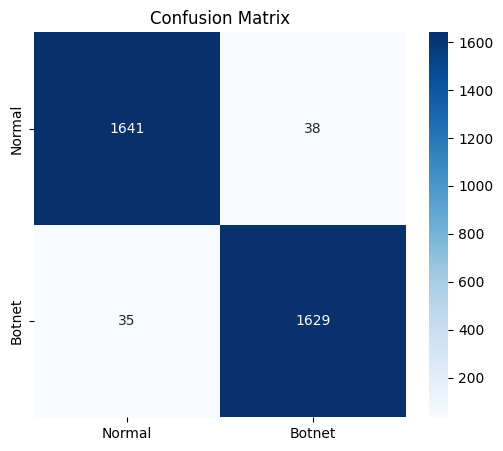

In [4]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Botnet'], yticklabels=['Normal', 'Botnet'])
plt.title("Confusion Matrix")
plt.show()